# Loan Risk Analysis and Feature Engineering

This project explores a synthetic loan applicant dataset to understand loan risk through data cleaning, exploratory data analysis (EDA), outlier handling, and feature engineering.

The goal is to prepare the dataset for a future machine learning model that can predict whether a loan applicant is likely to default.

### Project Workflow

1. Load and understand the dataset
2. Check data quality and missing values
3. Clean invalid and missing data
4. Explore important patterns and relationships
5. Detect and handle outliers
6. Create meaningful features
7. Analyze default behavior
8. Prepare the final dataset for machine learning

> **Note:** This dataset is synthetically generated for educational and practice purposes. It does not represent real applicants, financial institutions, or real-world credit decisions.

### Dataset Features

- `loan_id` — unique identifier for each loan application
- `age` — applicant's age
- `income` — applicant's annual income
- `loan_amount` — requested loan amount
- `credit_score` — applicant's credit score
- `default` — target variable (1 = defaulted, 0 = did not default)

### Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### Load Dataset

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/uzmajawed/loan-risk-dataset-for-eda-and-feature-engineering/loan_data.csv"
)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 1000
Columns: 6


### Preview the Dataset

In [4]:
# Display the first five rows

df.head()

,loan_id,age,income,loan_amount,credit_score,default
0,1001,22,71498.22,8650,655,1
1,1002,58,51372.80,15829,583,0
2,1003,52,NaN,13771,617,0
3,1004,40,49148.25,13291,689,0
4,1005,40,47443.89,13189,435,0


### Dataset Structure

In [5]:
# Check dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


### Basic Statistical Summary

In [6]:
# Generate descriptive statistics for numerical columns

df.describe()

,loan_id,age,income,loan_amount,credit_score,default
count,1000.00,1000.00,949.00,1000.00,1000.00,1000.00
mean,1500.50,43.64,49565.92,18373.14,552.57,0.19
std,288.82,15.00,15263.68,27133.78,146.93,0.39
min,1001.00,18.00,4000.00,-10021.00,300.00,0.00
25%,1250.75,30.00,39597.41,9810.00,443.75,0.00
50%,1500.50,44.00,49971.20,14250.00,559.00,0.00
75%,1750.25,57.00,59492.87,21223.75,658.00,0.00
max,2000.00,69.00,95000.00,459300.00,849.00,1.00


### Check Missing Values

In [7]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
loan_id          0
age              0
income          51
loan_amount      0
credit_score     0
default          0
dtype: int64


### Check Duplicate Records

In [8]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Check Unique Loan IDs

In [9]:
# Check whether loan_id contains unique values

unique_loan_ids = df['loan_id'].nunique()

print(f"Total rows: {len(df)}")
print(f"Unique loan IDs: {unique_loan_ids}")

if unique_loan_ids == len(df):
    print("loan_id is unique for every record.")
else:
    print("Duplicate loan IDs found.")

Total rows: 1000
Unique loan IDs: 1000
loan_id is unique for every record.


## Data Cleaning

### Handle Missing Income Values

In [10]:
# Handle missing income values

missing_income_before = df['income'].isnull().sum()
income_median = df['income'].median()

print(f"Missing income values before imputation: {missing_income_before}")
print(f"Median income: {income_median:,.2f}")

# Fill missing income values with the median
df['income'] = df['income'].fillna(income_median)

missing_income_after = df['income'].isnull().sum()

print(f"Missing income values after imputation: {missing_income_after}")

Missing income values before imputation: 51
Median income: 49,971.20
Missing income values after imputation: 0


### Check Invalid Loan Amounts

In [11]:
# Identify invalid negative loan amounts

negative_loans = df[df['loan_amount'] < 0]

print(f"Number of negative loan amounts: {len(negative_loans)}")

negative_loans[['loan_id', 'loan_amount']]

Number of negative loan amounts: 3


,loan_id,loan_amount
446,1447,-10021
482,1483,-3823
887,1888,-5257


### Handle Invalid Loan Amounts

In [12]:
# Replace invalid negative loan amounts with NaN

df.loc[df['loan_amount'] < 0, 'loan_amount'] = np.nan

print(f"Missing loan amounts after removing invalid values: {df['loan_amount'].isnull().sum()}")

Missing loan amounts after removing invalid values: 3


### Impute Invalid Loan Amounts

In [13]:
# Calculate median from valid loan amounts

loan_amount_median = df['loan_amount'].median()

# Fill invalid/missing loan amounts
df['loan_amount'] = df['loan_amount'].fillna(loan_amount_median)

print(f"Median valid loan amount: {loan_amount_median:,.2f}")
print(f"Missing loan amounts after imputation: {df['loan_amount'].isnull().sum()}")

Median valid loan amount: 14,278.00
Missing loan amounts after imputation: 0


### Verify Cleaned Data

In [14]:
# Final missing-value check

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
loan_id         0
age             0
income          0
loan_amount     0
credit_score    0
default         0
dtype: int64


## Exploratory Data Analysis

### Distribution of Default

In [15]:
# Count default and non-default cases

default_counts = df['default'].value_counts().sort_index()

print("Default distribution:")
print(default_counts)

print("\nDefault percentage:")
print((df['default'].value_counts(normalize=True).sort_index() * 100).round(2))

Default distribution:
default
0    813
1    187
Name: count, dtype: int64

Default percentage:
default
0   81.30
1   18.70
Name: proportion, dtype: float64


### Visualize Default Distribution

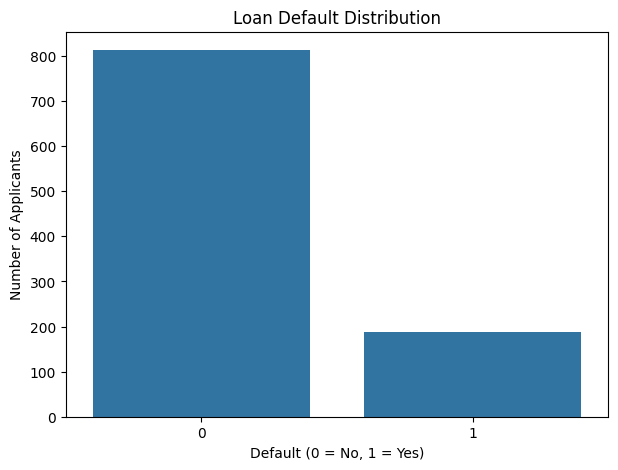

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='default')

plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Applicants")
plt.show()

### Age Distribution

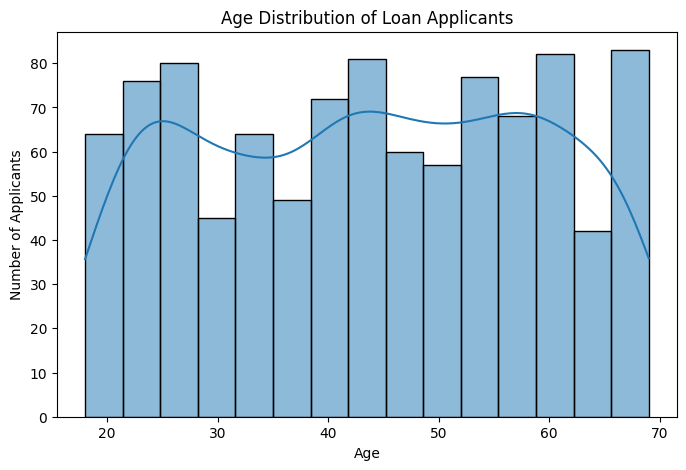

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', bins=15, kde=True)

plt.title("Age Distribution of Loan Applicants")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")
plt.show()

### Income Distribution

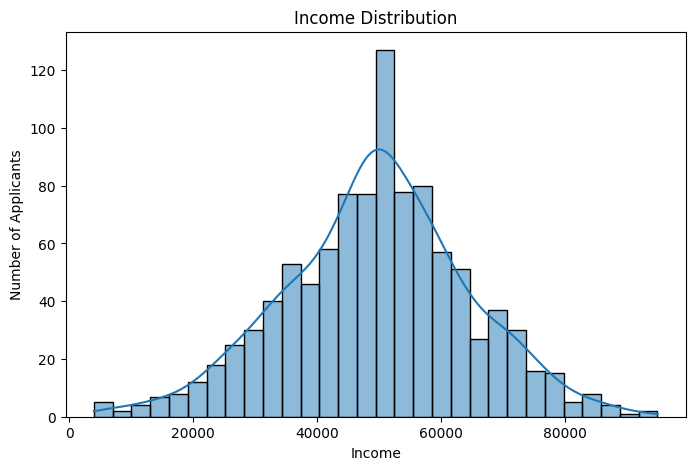

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='income', bins=30, kde=True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Applicants")
plt.show()

### Credit Score Distribution

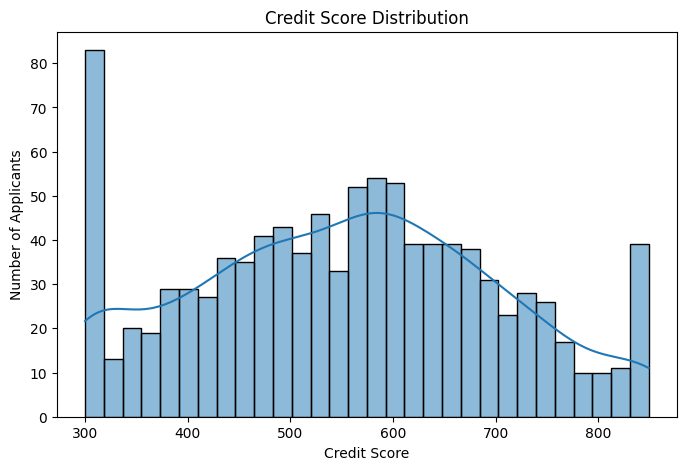

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='credit_score', bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.show()

### Loan Amount Distribution

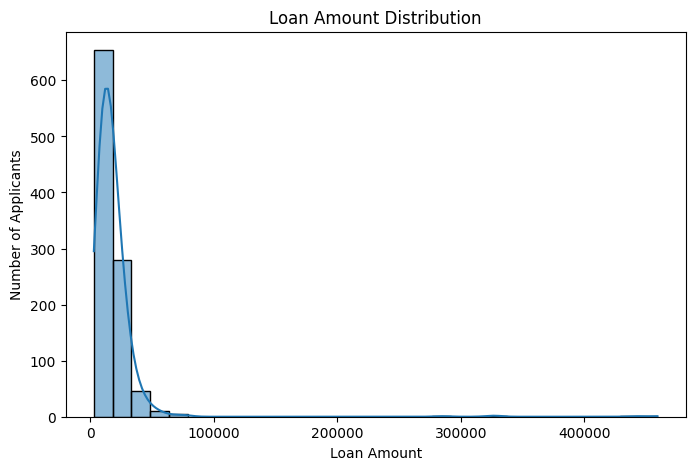

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='loan_amount', bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.show()

Correlation Analysis

Correlation Matrix

In [21]:
# Calculate correlations between numerical variables

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,loan_id,age,income,loan_amount,credit_score,default
loan_id,1.00,-0.00,0.04,-0.02,0.06,-0.05
age,-0.00,1.00,0.03,0.04,-0.02,0.03
income,0.04,0.03,1.00,0.01,-0.05,-0.05
loan_amount,-0.02,0.04,0.01,1.00,0.06,-0.01
credit_score,0.06,-0.02,-0.05,0.06,1.00,-0.20
default,-0.05,0.03,-0.05,-0.01,-0.20,1.00


### Correlation Heatmap

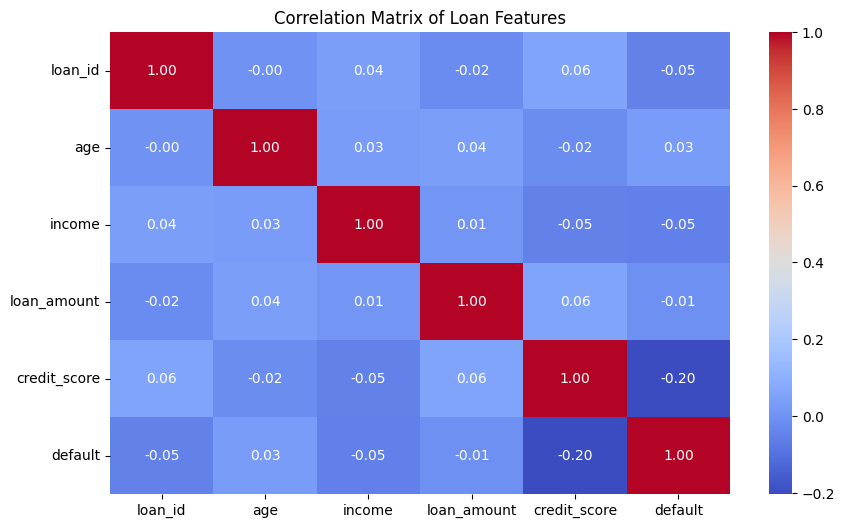

In [22]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Loan Features")
plt.show()

## Outlier Detection

### Loan Amount Boxplot

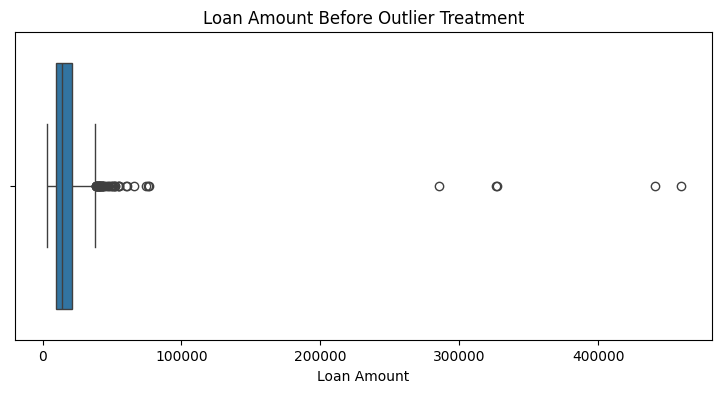

In [23]:
plt.figure(figsize=(9, 4))

sns.boxplot(x=df['loan_amount'])

plt.title("Loan Amount Before Outlier Treatment")
plt.xlabel("Loan Amount")
plt.show()

### Identify Percentile Limits

In [24]:
# Calculate percentile limits for extreme loan amounts

lower_limit = df['loan_amount'].quantile(0.05)
upper_limit = df['loan_amount'].quantile(0.95)

print(f"5th percentile:  {lower_limit:,.2f}")
print(f"95th percentile: {upper_limit:,.2f}")

5th percentile:  5,770.70
95th percentile: 36,294.25


### Create Cleaned Loan Amount Feature

In [25]:
# Clip extreme loan amounts using the 5th and 95th percentiles

df['loan_amount_cleaned'] = df['loan_amount'].clip(
    lower=lower_limit,
    upper=upper_limit
)

print("loan_amount_cleaned created successfully.")

loan_amount_cleaned created successfully.


### Compare Before and After

In [26]:
# Compare original and cleaned loan amount statistics

comparison = pd.DataFrame({
    'Original Loan Amount': df['loan_amount'].describe(),
    'Cleaned Loan Amount': df['loan_amount_cleaned'].describe()
})

comparison

,Original Loan Amount,Cleaned Loan Amount
count,1000.00,1000.00
mean,18435.07,16348.90
std,27100.36,8313.30
min,2911.00,5770.70
25%,9852.50,9852.50
50%,14278.00,14278.00
75%,21223.75,21223.75
max,459300.00,36294.25


### Cleaned Loan Amount Boxplot

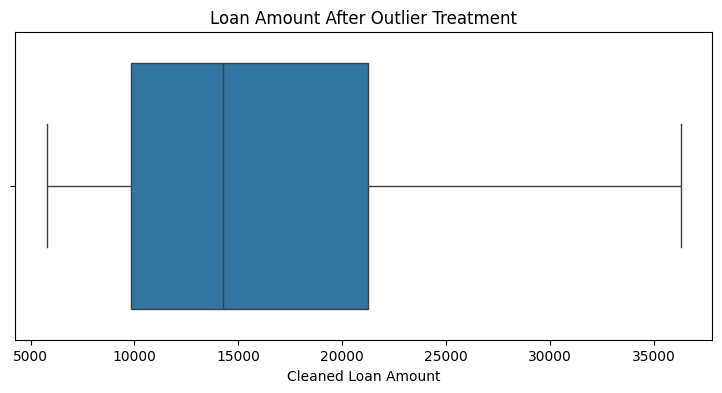

In [27]:
plt.figure(figsize=(9, 4))

sns.boxplot(x=df['loan_amount_cleaned'])

plt.title("Loan Amount After Outlier Treatment")
plt.xlabel("Cleaned Loan Amount")
plt.show()

## Feature Engineering
 
### Debt-to-Income Ratio

In [28]:
# Create Debt-to-Income ratio

df['dti_ratio'] = df['loan_amount_cleaned'] / df['income']

print("DTI ratio created successfully.")


DTI ratio created successfully.


### Inspect DTI Ratio

In [29]:
# Summary statistics for DTI ratio

df['dti_ratio'].describe()

count   1000.00
mean       0.39
std        0.39
min        0.06
25%        0.19
50%        0.30
75%        0.47
max        6.68
Name: dti_ratio, dtype: float64

### DTI Distribution

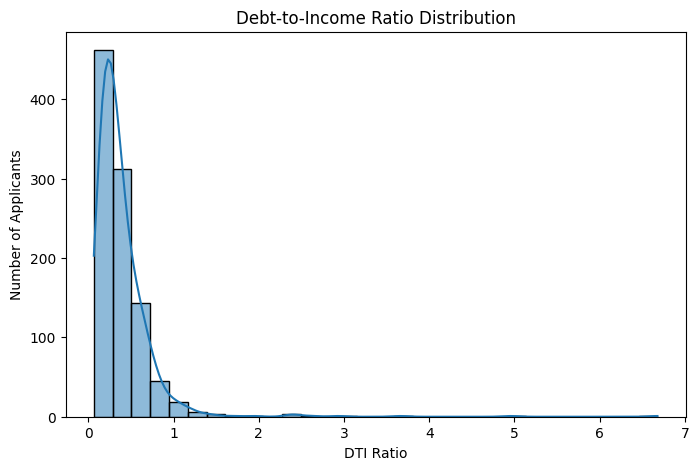

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='dti_ratio', bins=30, kde=True)

plt.title("Debt-to-Income Ratio Distribution")
plt.xlabel("DTI Ratio")
plt.ylabel("Number of Applicants")
plt.show()

### Create Credit Risk Categories

In [31]:
# Create risk categories based on credit score

bins = [299, 579, 669, 739, 850]
labels = ['High Risk', 'Fair', 'Good', 'Excellent']

df['risk_category'] = pd.cut(
    df['credit_score'],
    bins=bins,
    labels=labels
)

df[['credit_score', 'risk_category']].head(10)

,credit_score,risk_category
0,655,Fair
1,583,Fair
2,617,Fair
3,689,Good
4,435,High Risk
5,705,Good
6,345,High Risk
7,617,Fair
8,593,Fair
9,466,High Risk


### Check Risk Category Distribution

In [32]:
# Count applicants in each risk category

risk_counts = df['risk_category'].value_counts().sort_index()

print(risk_counts)

risk_category
High Risk    559
Fair         216
Good         112
Excellent    113
Name: count, dtype: int64


### Visualize Risk Categories

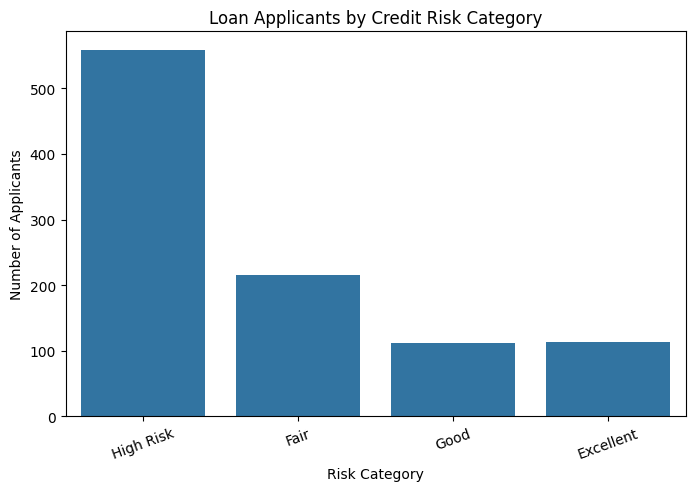

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='risk_category',
    order=labels
)

plt.title("Loan Applicants by Credit Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=20)
plt.show()

## Risk Analysis

### Default Rate by Risk Category

In [34]:
# Calculate default rate for each risk category

risk_default_rate = (
    df.groupby('risk_category', observed=False)['default']
      .mean()
      .mul(100)
      .round(2)
)

risk_default_rate

risk_category
High Risk   24.69
Fair        13.89
Good        10.71
Excellent    6.19
Name: default, dtype: float64

### Visualize Default Rate

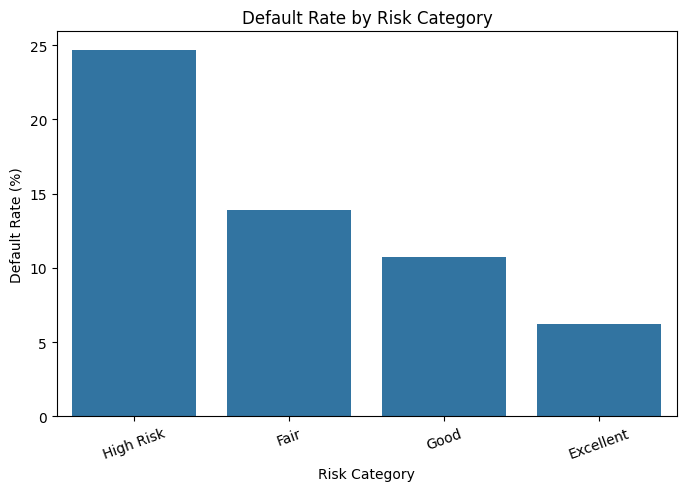

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_default_rate.index,
    y=risk_default_rate.values
)

plt.title("Default Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

### Default Rate by Credit Score

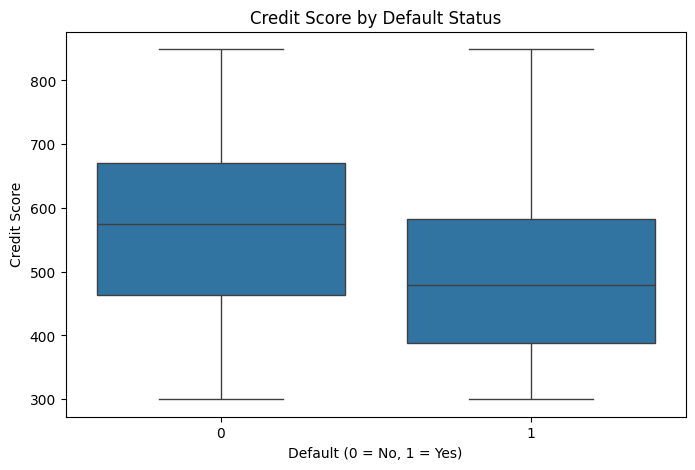

In [36]:
# Compare credit score distributions between default groups

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='default',
    y='credit_score'
)

plt.title("Credit Score by Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Credit Score")
plt.show()

### Default Rate by DTI

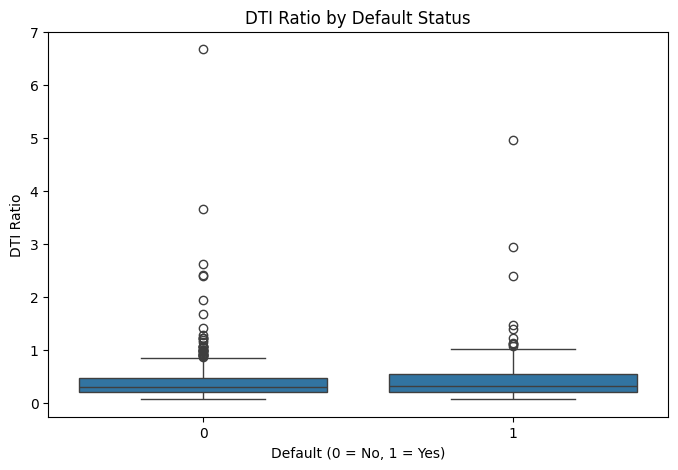

In [37]:
# Compare DTI ratio between default groups

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='default',
    y='dti_ratio'
)

plt.title("DTI Ratio by Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("DTI Ratio")
plt.show()

## Final Dataset

### Review Engineered Dataset

In [38]:
# Display the final dataset with engineered features

df.head()

,loan_id,age,income,loan_amount,credit_score,default,loan_amount_cleaned,dti_ratio,risk_category
0,1001,22,71498.22,8650.00,655,1,8650.00,0.12,Fair
1,1002,58,51372.80,15829.00,583,0,15829.00,0.31,Fair
2,1003,52,49971.20,13771.00,617,0,13771.00,0.28,Fair
3,1004,40,49148.25,13291.00,689,0,13291.00,0.27,Good
4,1005,40,47443.89,13189.00,435,0,13189.00,0.28,High Risk


### Final Dataset Information

In [39]:
# Check final dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   loan_id              1000 non-null   int64   
 1   age                  1000 non-null   int64   
 2   income               1000 non-null   float64 
 3   loan_amount          1000 non-null   float64 
 4   credit_score         1000 non-null   int64   
 5   default              1000 non-null   int64   
 6   loan_amount_cleaned  1000 non-null   float64 
 7   dti_ratio            1000 non-null   float64 
 8   risk_category        1000 non-null   category
dtypes: category(1), float64(4), int64(4)
memory usage: 63.8 KB


### Final Missing-Value Check

In [40]:
# Confirm that the final dataset contains no missing values

final_missing = df.isnull().sum()

print("Final missing-value check:")
print(final_missing)

Final missing-value check:
loan_id                0
age                    0
income                 0
loan_amount            0
credit_score           0
default                0
loan_amount_cleaned    0
dti_ratio              0
risk_category          0
dtype: int64


### Final Feature List

In [41]:
# Display all features in the final dataset

print("Final features:")
for column in df.columns:
    print(f"- {column}")

Final features:
- loan_id
- age
- income
- loan_amount
- credit_score
- default
- loan_amount_cleaned
- dti_ratio
- risk_category


### Final Summary Statistics

In [42]:
# Final numerical summary

df.describe()

,loan_id,age,income,loan_amount,credit_score,default,loan_amount_cleaned,dti_ratio
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,1500.50,43.64,49586.59,18435.07,552.57,0.19,16348.90,0.39
std,288.82,15.00,14869.23,27100.36,146.93,0.39,8313.30,0.39
min,1001.00,18.00,4000.00,2911.00,300.00,0.00,5770.70,0.06
25%,1250.75,30.00,40421.70,9852.50,443.75,0.00,9852.50,0.19
50%,1500.50,44.00,49971.20,14278.00,559.00,0.00,14278.00,0.30
75%,1750.25,57.00,58817.47,21223.75,658.00,0.00,21223.75,0.47
max,2000.00,69.00,95000.00,459300.00,849.00,1.00,36294.25,6.68


## Key Statistics

### Generate Key Statistics

In [43]:
# Calculate key project statistics

total_applicants = len(df)
defaulted_applicants = df['default'].sum()
default_rate = df['default'].mean() * 100

highest_risk_rate = risk_default_rate.max()
lowest_risk_rate = risk_default_rate.min()

print(f"Total applicants: {total_applicants}")
print(f"Defaulted applicants: {defaulted_applicants}")
print(f"Overall default rate: {default_rate:.2f}%")
print(f"Highest category default rate: {highest_risk_rate:.2f}%")
print(f"Lowest category default rate: {lowest_risk_rate:.2f}%")

Total applicants: 1000
Defaulted applicants: 187
Overall default rate: 18.70%
Highest category default rate: 24.69%
Lowest category default rate: 6.19%


## Key Findings

### 1. Data Quality
- The dataset contains 1,000 loan applications.
- Missing values were found in the `income` column.
- Missing income values were handled using median imputation.
- A small number of negative `loan_amount` values were identified as invalid and replaced using the median of valid loan amounts.

### 2. Outlier Treatment
- Extreme loan amounts were identified using a boxplot.
- A separate `loan_amount_cleaned` feature was created.
- The 5th and 95th percentile values were used as limits for clipping extreme loan amounts.

### 3. Feature Engineering
Two new features were created:

- `dti_ratio` — loan amount relative to applicant income, used as a proxy for repayment burden.
- `risk_category` — credit-score-based risk category.

### 4. Risk Analysis
Default rates were compared across the engineered credit-risk categories.

The analysis helps determine whether credit-score-based categories show a meaningful relationship with loan default behavior.

### 5. Final Dataset
The final dataset contains the original loan information together with the engineered features required for further analysis or a future machine-learning classification stage.

# Project Conclusion

This project analyzed a synthetic loan dataset to understand applicant risk and prepare the data for further machine-learning work.

The analysis covered:

- Dataset inspection
- Missing-value handling
- Duplicate checking
- Invalid-value detection
- Exploratory data analysis
- Correlation analysis
- Outlier detection
- Outlier treatment
- Debt-to-Income ratio creation
- Credit-score risk categorization
- Default-rate analysis

The final dataset is now cleaned and enriched with meaningful features.

The analysis indicates that credit-score-based risk categories can be useful for understanding differences in default behavior.